In [1]:
import sys
sys.path.append("../backend")

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("text_data.csv")
df.head()

,Unnamed: 0,Text,Author
0,0,This study investigates the chemical compositi...,AI
1,1,This study explores the cultural history of oi...,AI
2,2,Isolation of human peripheral blood mononucle...,Human
3,3,Dynamic Bayesian Networks (DBNs) are probabil...,Human
4,4,"Within volleyball, performance analysis is em...",Human


In [4]:
df.columns

Index(['Unnamed: 0', 'Text', 'Author'], dtype='str')

In [5]:
df.drop("Unnamed: 0",axis=1,inplace=True)

In [6]:
df.head()

,Text,Author
0,This study investigates the chemical compositi...,AI
1,This study explores the cultural history of oi...,AI
2,Isolation of human peripheral blood mononucle...,Human
3,Dynamic Bayesian Networks (DBNs) are probabil...,Human
4,"Within volleyball, performance analysis is em...",Human


In [7]:
df.shape

(6069, 2)

In [8]:
df.isnull().sum()

Text      0
Author    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
from perplexity import calculate_perplexity
from burstiness import calculate_burstiness

f:\AI Score Detector\backend\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 7727.49it/s]


In [11]:
sample_text = df["Text"][0] 

print(sample_text)
print()
print("Perplexity : ",calculate_perplexity(sample_text))
print("Burstiness : ",calculate_burstiness(sample_text))

This study investigates the chemical composition of thermal springs in Afyonkarahisar, assessing their potential for health tourism.



[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Perplexity :  245.06
Burstiness :  0


In [12]:
sample_text = df["Text"][10] 

print(sample_text)
print()
print("Perplexity : ",calculate_perplexity(sample_text))
print("Burstiness : ",calculate_burstiness(sample_text))

AI for history. We used computer vision to piece together fragments of the "Cairo Genizah" manuscripts. The AI matched handwriting styles and paper fiber patterns across thousands of fragments. It successfully reconstructed lost texts from the 11th century, revolutionizing the study of medieval history.

Perplexity :  59.28
Burstiness :  5.42


In [13]:
perplexities = []
burstiness_scores = []

for text in df["Text"]:
    try:
        perplexity = calculate_perplexity(text)
        burstiness = calculate_burstiness(text)
    
    except Exception as e:
        print("Error :",e)
        perplexity = None
        burstiness = None

    perplexities.append(perplexity)
    burstiness_scores.append(burstiness)



In [14]:
df["perplexity"] = perplexities
df["burstiness"] = burstiness_scores

In [15]:
df.head()

,Text,Author,perplexity,burstiness
0,This study investigates the chemical compositi...,AI,245.06,0.00
1,This study explores the cultural history of oi...,AI,148.59,0.00
2,Isolation of human peripheral blood mononucle...,Human,7.23,7.39
3,Dynamic Bayesian Networks (DBNs) are probabil...,Human,26.33,18.43
4,"Within volleyball, performance analysis is em...",Human,33.62,8.88


In [16]:
df.describe()

,perplexity,burstiness
count,6069.000000,6069.000000
mean,49.369166,7.698122
std,48.376329,4.020748
min,4.330000,0.000000
25%,24.300000,5.510000
50%,39.780000,7.810000
75%,61.870000,10.020000
max,1648.540000,52.040000


In [17]:
df.to_csv(
    "outputs/processed_dataset.csv",
    index=False
)

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("outputs/processed_dataset.csv")

In [5]:
df.head()

,Text,Author,perplexity,burstiness
0,This study investigates the chemical compositi...,AI,245.06,0.00
1,This study explores the cultural history of oi...,AI,148.59,0.00
2,Isolation of human peripheral blood mononucle...,Human,7.23,7.39
3,Dynamic Bayesian Networks (DBNs) are probabil...,Human,26.33,18.43
4,"Within volleyball, performance analysis is em...",Human,33.62,8.88


In [6]:
df['Author'].value_counts()

Author
AI       3069
Human    3000
Name: count, dtype: int64

In [7]:
df.groupby("Author")[["perplexity","burstiness"]].mean()

,perplexity,burstiness
Author,,
AI,71.072731,6.049009
Human,27.166420,9.385163


<Figure size 800x500 with 0 Axes>

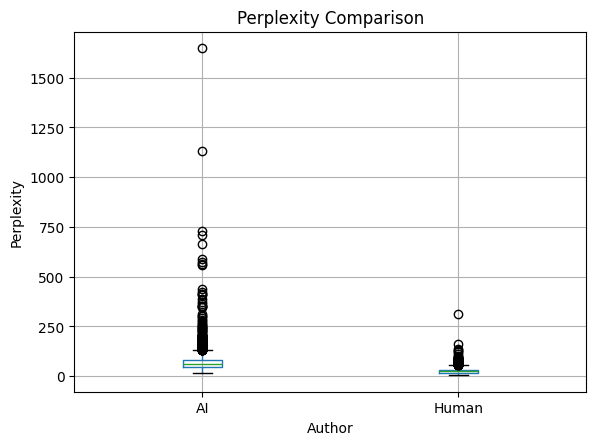

In [8]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="perplexity",
    by="Author"
)

plt.title("Perplexity Comparison")
plt.suptitle("")

plt.xlabel("Author")
plt.ylabel("Perplexity")

plt.show()

<Figure size 800x500 with 0 Axes>

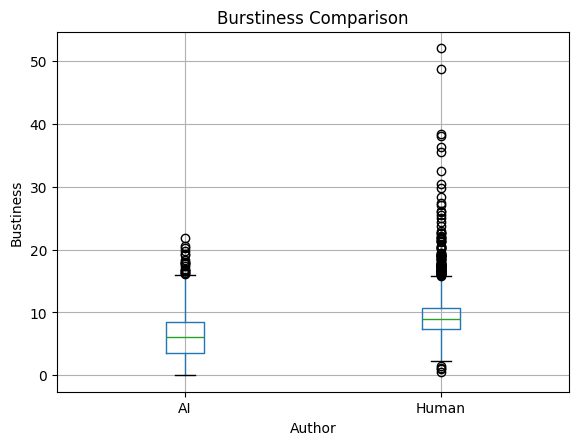

In [9]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="burstiness",
    by="Author"
)

plt.title("Burstiness Comparison")
plt.suptitle("")

plt.xlabel("Author")
plt.ylabel("Bustiness")

plt.show()

Burstiness shows a stronger signal, as human writing tends to have more variation in sentence structure. Perplexity behaved unexpectedly, with AI text showing higher values than human text, likely due to dataset characteristics or GPT-2 limitations.

# Baseline Model (Logistic Regression)

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report

In [13]:
X = df[["perplexity","burstiness"]]
y = df["Author"]


X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [15]:
model = LogisticRegression()
model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [16]:
y_pred = model.predict(X_test)
y_pred

array(['AI', 'Human', 'Human', ..., 'Human', 'Human', 'Human'],
      shape=(1214,), dtype=object)

In [22]:
accuracy = accuracy_score(y_test,y_pred)
cm = confusion_matrix(y_test,y_pred)
classification_report = classification_report(y_test,y_pred)

print("Accuracy score : ",accuracy)
print("confusion_matrix :",cm)
print("classification_report :\n",classification_report)

Accuracy score :  0.8789126853377265
confusion_matrix : [[539 100]
 [ 47 528]]
classification_report :
               precision    recall  f1-score   support

          AI       0.92      0.84      0.88       639
       Human       0.84      0.92      0.88       575

    accuracy                           0.88      1214
   macro avg       0.88      0.88      0.88      1214
weighted avg       0.88      0.88      0.88      1214



- Getting 88% accuracy using only perplexity and burstiness was better than expected for such a simple approach.
- AI precision of 0.92 means the model usually predicted AI-generated text correctly, with few false positives.
- Human recall of 0.92 shows the model successfully identified most human-written samples.
- The model more often confused AI text as human, which reflects how modern LLM outputs are becoming increasingly natural.

Overall, the results showed that simple handcrafted features can still build an effective AI-text detection baseline.

In [23]:
print(model.coef_)

[[-0.10741995  0.24404564]]


In [24]:
model.classes_

array(['AI', 'Human'], dtype=object)

Through logistic regression, we can understand that burstiness had the strongest positive influence on identifying text as human-written, meaning texts with greater variation in sentence structure were more likely to be classified as human. On the other hand, perplexity showed a negative influence, indicating that higher perplexity values increased the likelihood of the text being classified as AI-generated in this dataset.

# Feature Expansion

In [5]:
import re 
import pandas as pd

In [6]:
df = pd.read_csv("outputs/processed_dataset.csv")
df.head()

,Text,Author,perplexity,burstiness
0,This study investigates the chemical compositi...,AI,245.06,0.00
1,This study explores the cultural history of oi...,AI,148.59,0.00
2,Isolation of human peripheral blood mononucle...,Human,7.23,7.39
3,Dynamic Bayesian Networks (DBNs) are probabil...,Human,26.33,18.43
4,"Within volleyball, performance analysis is em...",Human,33.62,8.88


In [7]:
def average_sentence_length(text):

    sentences = re.split(r"[.!?]+", text)
    sentences = [s for s in sentences if s.strip()]

    if len(sentences) == 0:
        return 0

    words = re.findall(r"\b\w+\b", text)

    return len(words) / len(sentences)

In [8]:
sample_text = df["Text"][0]

print(average_sentence_length(sample_text))

17.0


In [9]:
avg_sentence_len = []

for text in df["Text"]:
    avg_len = average_sentence_length(text)
    avg_sentence_len.append(avg_len)

In [11]:
df['avg_sentence_length'] = avg_sentence_len

In [12]:
df.head(2)

,Text,Author,perplexity,burstiness,avg_sentence_length
0,This study investigates the chemical compositi...,AI,245.06,0.0,17.0
1,This study explores the cultural history of oi...,AI,148.59,0.0,23.0


In [14]:
df.groupby("Author")['avg_sentence_length'].mean()

Author
AI       16.015250
Human    19.425355
Name: avg_sentence_length, dtype: float64

human writing tends to use longer sentences on average

In [15]:
# feature 2 vocabulary_diversity

def vocabulary_diversity(text):
    words = re.findall(r"\b\w+\b",text.lower())

    if len(words) == 0:
        return 0 
    
    unique_words = set(words)
    return len(unique_words) / len(words)

sample_text = df["Text"][0]

print(vocabulary_diversity(sample_text))

1.0


In [16]:
vocabulary_diversitys = []

for text in df["Text"]:
    vd = vocabulary_diversity(text)
    vocabulary_diversitys.append(vd)


df['vocabulary_diversity'] = vocabulary_diversitys

In [17]:
df.groupby("Author")["vocabulary_diversity"].mean()

Author
AI       0.862989
Human    0.575191
Name: vocabulary_diversity, dtype: float64

In this dataset, AI-generated samples exhibited significantly higher vocabulary diversity, which may be due to the characteristics of the dataset, even though human-written text usually has richer vocabulary.

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [19]:
X = df[["perplexity","burstiness","avg_sentence_length","vocabulary_diversity"]]
y = df["Author"]


X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [20]:
model = LogisticRegression()
model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [23]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
cm = confusion_matrix(y_test,y_pred)
classification_report = classification_report(y_test,y_pred)

print("Accuracy score : ",accuracy)
print("confusion_matrix :",cm)
print("classification_report :\n",classification_report)

Accuracy score :  0.9769357495881383
confusion_matrix : [[625  14]
 [ 14 561]]
classification_report :
               precision    recall  f1-score   support

          AI       0.98      0.98      0.98       639
       Human       0.98      0.98      0.98       575

    accuracy                           0.98      1214
   macro avg       0.98      0.98      0.98      1214
weighted avg       0.98      0.98      0.98      1214



## Conclusion

The expanded feature set significantly improved the model performance compared to the initial baseline model. Features such as burstiness, average sentence length, and vocabulary diversity helped the model better capture stylistic differences between AI-generated and human-written text. 

The Logistic Regression model achieved around 97% accuracy on the selected dataset, showing that handcrafted linguistic features can provide strong classification signals. Burstiness showed a strong human-writing pattern, while vocabulary diversity and perplexity contributed heavily toward AI classification in this dataset.

However, the results may also be influenced by dataset-specific writing patterns, so the model should not be considered a perfect real-world AI detector. The project demonstrates how feature engineering, NLP analysis, and machine learning can be combined to build an interpretable AI text analysis system.

In [24]:
import joblib

joblib.dump(model, "outputs/ai_text_detector_model.pkl")

feature_columns = [
    "perplexity",
    "burstiness",
    "avg_sentence_length",
    "vocabulary_diversity"
]

joblib.dump(
    feature_columns,
    "outputs/feature_columns.pkl"
)

['outputs/feature_columns.pkl']